In [6]:
import sys
print(sys.executable)


c:\Users\DELL\Documents\silent-killer-ai-cvd\.venv\Scripts\python.exe


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Everything works!")

Everything works!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [9]:
# Load the SAHeart dataset
df = pd.read_csv("../data/raw/SAHeart.csv")

# Display the first five rows
df.head()

,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,1,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,2,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,3,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,4,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,5,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


In [10]:
# Display dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row.names  462 non-null    int64  
 1   sbp        462 non-null    int64  
 2   tobacco    462 non-null    float64
 3   ldl        462 non-null    float64
 4   adiposity  462 non-null    float64
 5   famhist    462 non-null    str    
 6   typea      462 non-null    int64  
 7   obesity    462 non-null    float64
 8   alcohol    462 non-null    float64
 9   age        462 non-null    int64  
 10  chd        462 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 42.7 KB


In [11]:
# Summary statistics
df.describe()

,row.names,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,231.935065,138.326840,3.635649,4.740325,25.406732,53.103896,26.044113,17.044394,42.816017,0.346320
std,133.938585,20.496317,4.593024,2.070909,7.780699,9.817534,4.213680,24.481059,14.608956,0.476313
min,1.000000,101.000000,0.000000,0.980000,6.740000,13.000000,14.700000,0.000000,15.000000,0.000000
25%,116.250000,124.000000,0.052500,3.282500,19.775000,47.000000,22.985000,0.510000,31.000000,0.000000
50%,231.500000,134.000000,2.000000,4.340000,26.115000,53.000000,25.805000,7.510000,45.000000,0.000000
75%,347.750000,148.000000,5.500000,5.790000,31.227500,60.000000,28.497500,23.892500,55.000000,1.000000
max,463.000000,218.000000,31.200000,15.330000,42.490000,78.000000,46.580000,147.190000,64.000000,1.000000


In [12]:
# Check for missing values
df.isnull().sum()

row.names    0
sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

In [13]:
print("Rows and Columns:", df.shape)

Rows and Columns: (462, 11)


The SAHeart dataset was loaded into a Pandas DataFrame. Initial inspection was performed to understand the dataset structure, variable types, dimensions, and the presence of missing values. Summary statistics were generated to understand the distribution of the numerical features before preprocessing.

## Data Cleaning

The dataset contains an additional column (`row.names`) that serves only as an identifier. Since it does not provide clinical information relevant to cardiovascular disease prediction, it was removed before further preprocessing.

In [14]:
# Remove unnecessary identifier column
df = df.drop(columns=["row.names"])

# Verify the remaining columns
df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


In [15]:
df.isnull().sum()


sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

Categorical Encoding: The famhist (family history) variable was converted from categorical text values to numerical values using binary encoding (Absent = 0, Present = 1). This transformation enables machine learning algorithms to process the variable while preserving its clinical meaning.

In [16]:
# Encode family history
df["famhist"] = df["famhist"].map({
    "Present": 1,
    "Absent": 0
})

# Verify the encoding
df["famhist"].value_counts()

famhist
0    270
1    192
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    int64  
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 36.2 KB


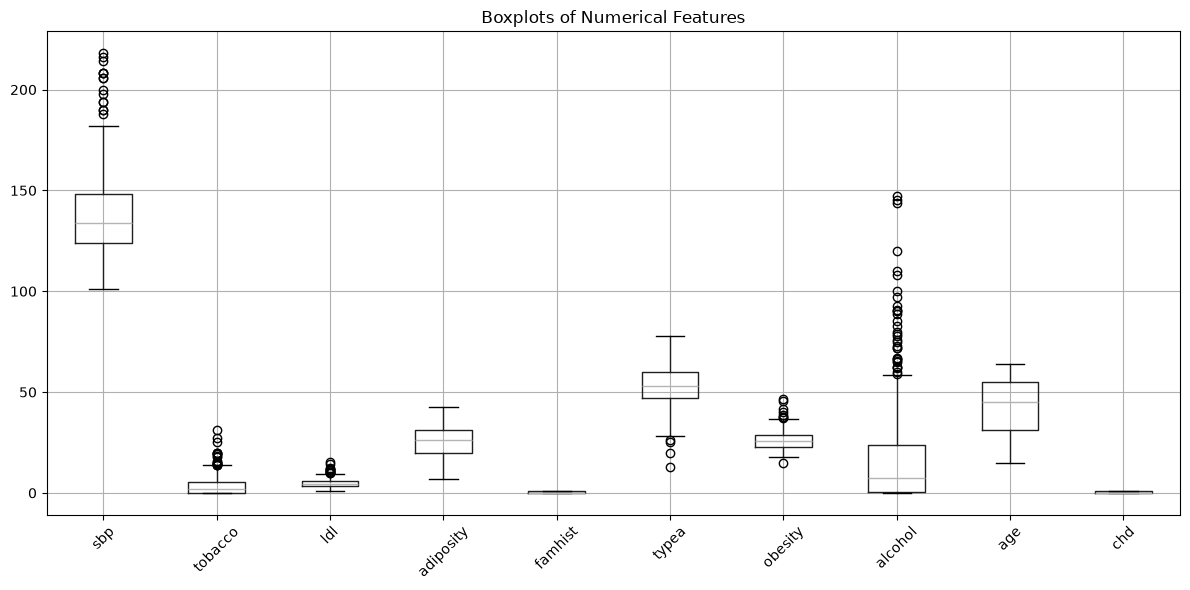

In [ ]:
import matplotlib.pyplot as plt

# Create boxplots for all numerical columns
df.boxplot(figsize=(12, 6), rot=45)

plt.title("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

## Feature Engineering

To capture the combined effect of age and systolic blood pressure on cardiovascular risk, a new interaction feature (Age × SBP) was created. This feature may help the model identify patients whose risk increases due to the combined influence of both factors.

In [ ]:
# Create Age × SBP interaction feature
df["age_sbp"] = df["age"] * df["sbp"]

# Display the first few rows
df[["age", "sbp", "age_sbp"]].head()

,age,sbp,age_sbp
0,52,160,8320
1,63,144,9072
2,46,118,5428
3,58,170,9860
4,49,134,6566


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("chd", axis=1)
y = df["chd"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
X_scaled.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,age_sbp
0,1.058564,1.823073,0.478412,-0.295503,1.185854,-0.418470,-0.176786,3.277738,0.629336,0.905242
1,0.277089,-0.790237,-0.159680,0.412140,-0.843274,0.193344,0.671373,-0.612745,1.383115,1.203652
2,-0.992806,-0.774980,-0.609245,0.884332,1.185854,-0.112563,0.735519,-0.541183,0.218184,-0.242363
3,1.546985,0.842264,0.807126,1.624141,1.185854,-0.214532,1.412621,0.295062,1.040488,1.516346
4,-0.211332,2.171805,-0.599577,0.305351,1.185854,0.703189,-0.012856,1.647775,0.423760,0.209219


In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (323, 10)
Validation set: (69, 10)
Test set: (70, 10)


# Phase 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to understand the characteristics of the SAHeart dataset before model development. Statistical summaries and visualizations were used to identify relationships between clinical variables and coronary heart disease (CHD). These insights informed feature selection and model development.

In [ ]:
import seaborn as sns

print("Seaborn installed successfully!")


Seaborn installed successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
# Summary statistics
df.describe()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd,age_sbp
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,138.326840,3.635649,4.740325,25.406732,0.415584,53.103896,26.044113,17.044394,42.816017,0.346320,6038.761905
std,20.496317,4.593024,2.070909,7.780699,0.493357,9.817534,4.213680,24.481059,14.608956,0.476313,2522.761614
min,101.000000,0.000000,0.980000,6.740000,0.000000,13.000000,14.700000,0.000000,15.000000,0.000000,1616.000000
25%,124.000000,0.052500,3.282500,19.775000,0.000000,47.000000,22.985000,0.510000,31.000000,0.000000,4020.000000
50%,134.000000,2.000000,4.340000,26.115000,0.000000,53.000000,25.805000,7.510000,45.000000,0.000000,6059.000000
75%,148.000000,5.500000,5.790000,31.227500,1.000000,60.000000,28.497500,23.892500,55.000000,1.000000,7785.000000
max,218.000000,31.200000,15.330000,42.490000,1.000000,78.000000,46.580000,147.190000,64.000000,1.000000,13608.000000


In [ ]:
# Compare patients with and without heart disease
df.groupby("chd").mean()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,age_sbp
chd,,,,,,,,,,
0,135.460265,2.634735,4.344238,23.969106,0.317881,52.36755,25.737450,15.931358,38.854305,5369.145695
1,143.737500,5.524875,5.487938,28.120250,0.600000,54.49375,26.622937,19.145250,50.293750,7302.662500


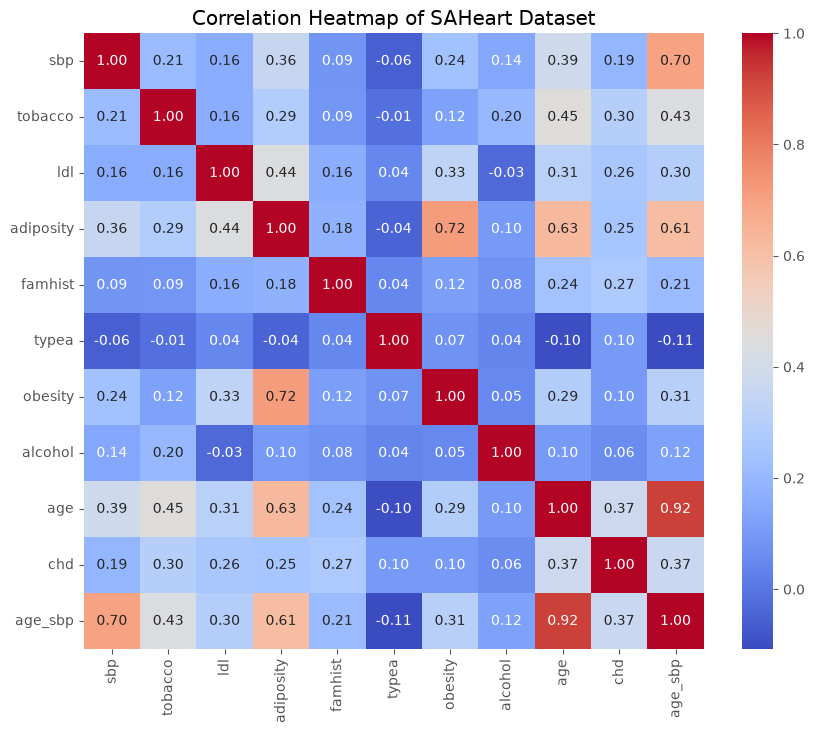

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of SAHeart Dataset")
plt.show()

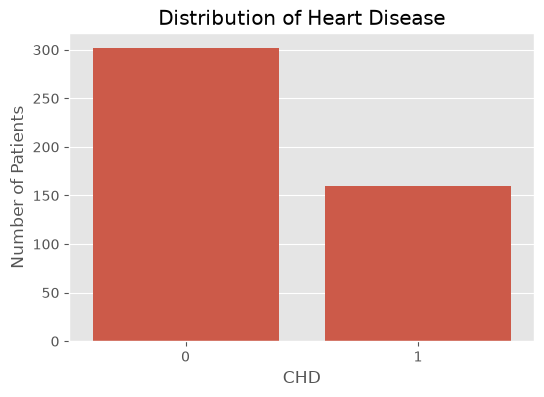

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="chd", data=df)

plt.title("Distribution of Heart Disease")
plt.xlabel("CHD")
plt.ylabel("Number of Patients")

plt.show()

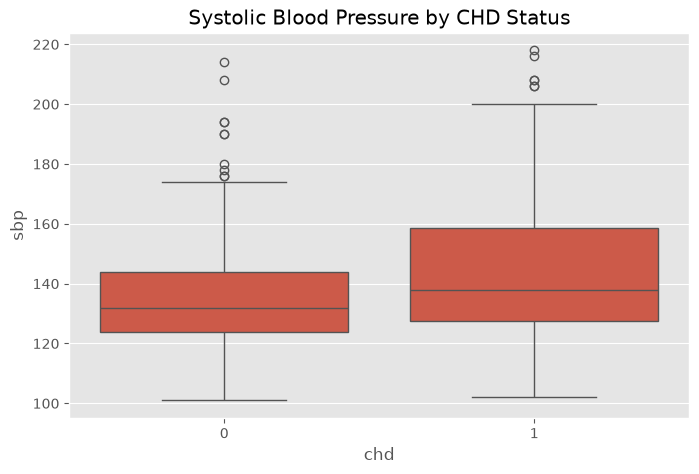

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="chd", y="sbp", data=df)

plt.title("Systolic Blood Pressure by CHD Status")

plt.show()

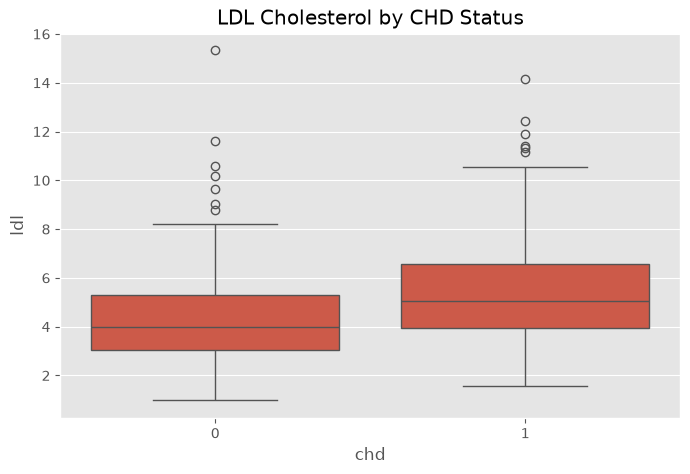

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="chd", y="ldl", data=df)

plt.title("LDL Cholesterol by CHD Status")

plt.show()

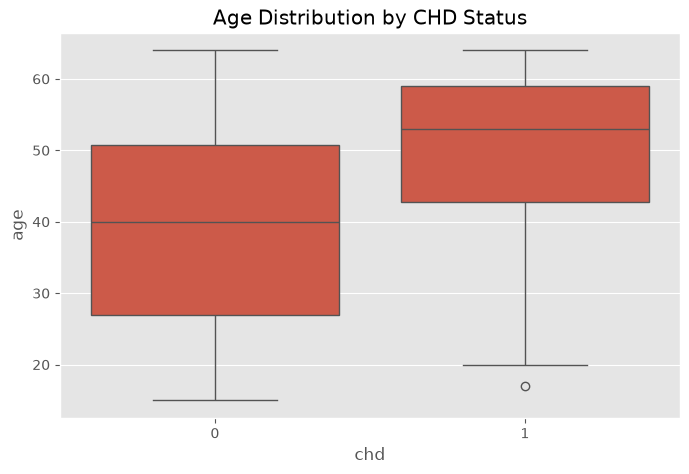

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="chd", y="age", data=df)

plt.title("Age Distribution by CHD Status")

plt.show()

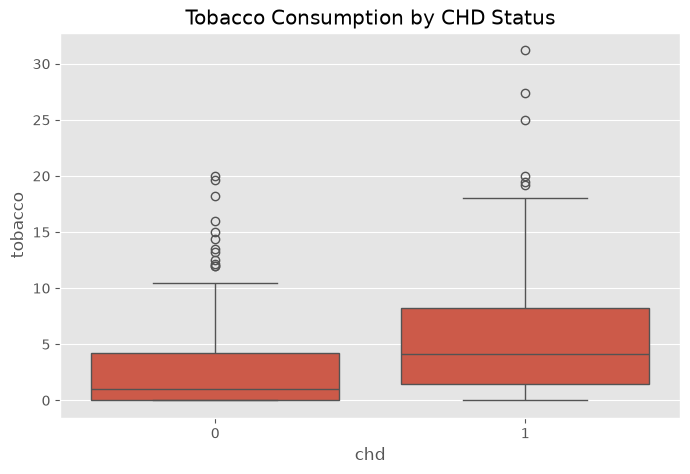

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="chd", y="tobacco", data=df)

plt.title("Tobacco Consumption by CHD Status")

plt.show()

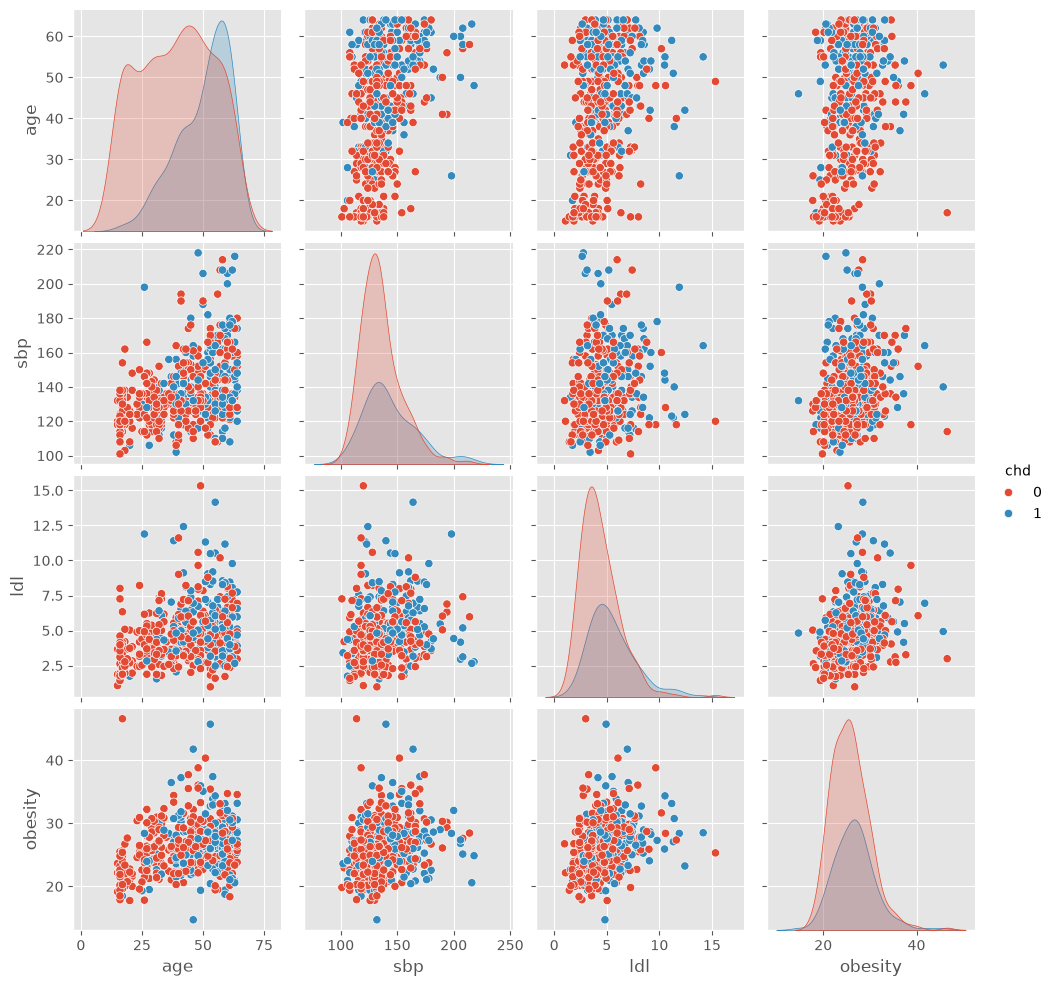

In [ ]:
sns.pairplot(
    df[["age","sbp","ldl","obesity","chd"]],
    hue="chd"
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("../data/raw/SAHeart.csv")


In [ ]:
df.describe()


,row.names,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,231.935065,138.326840,3.635649,4.740325,25.406732,53.103896,26.044113,17.044394,42.816017,0.346320
std,133.938585,20.496317,4.593024,2.070909,7.780699,9.817534,4.213680,24.481059,14.608956,0.476313
min,1.000000,101.000000,0.000000,0.980000,6.740000,13.000000,14.700000,0.000000,15.000000,0.000000
25%,116.250000,124.000000,0.052500,3.282500,19.775000,47.000000,22.985000,0.510000,31.000000,0.000000
50%,231.500000,134.000000,2.000000,4.340000,26.115000,53.000000,25.805000,7.510000,45.000000,0.000000
75%,347.750000,148.000000,5.500000,5.790000,31.227500,60.000000,28.497500,23.892500,55.000000,1.000000
max,463.000000,218.000000,31.200000,15.330000,42.490000,78.000000,46.580000,147.190000,64.000000,1.000000


In [20]:
df.groupby("chd").mean(numeric_only=True)


,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age
chd,,,,,,,,,
0,135.460265,2.634735,4.344238,23.969106,0.317881,52.36755,25.737450,15.931358,38.854305
1,143.737500,5.524875,5.487938,28.120250,0.600000,54.49375,26.622937,19.145250,50.293750


In [4]:
df = pd.read_csv("../data/raw/Heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.notnull().sum()

age         303
sex         303
cp          303
trestbps    303
chol        303
fbs         303
restecg     303
thalach     303
exang       303
oldpeak     303
slope       303
ca          303
thal        303
target      303
dtype: int64

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000
